In [4]:
!pip install -U datasets ipywidgets transformers

^C


  Using cached ipywidgets-8.1.7-py3-none-any.whl.metadata (2.4 kB)
  Using cached transformers-4.52.3-py3-none-any.whl.metadata (40 kB)
  Using cached jupyterlab_widgets-3.0.15-py3-none-any.whl.metadata (20 kB)
  Using cached tokenizers-0.21.1-cp39-abi3-win_amd64.whl.metadata (6.9 kB)
Using cached ipywidgets-8.1.7-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.15-py3-none-any.whl (216 kB)
Using cached transformers-4.52.3-py3-none-any.whl (10.5 MB)
Using cached tokenizers-0.21.1-cp39-abi3-win_amd64.whl (2.4 MB)

   ---------- ----------------------------- 1/4 [tokenizers]
   -------------------- ------------------- 2/4 [ipywidgets]
   -------------------- ------------------- 2/4 [ipywidgets]
   -------------------- ------------------- 2/4 [ipywidgets]
   ------------------------------ --------- 3/4 [transformers]
   ------------------------------ --------- 3/4 [transformers]
   ------------------------------ --------- 3/4 [transformers]
   ------------------------------ -

In [2]:
from datasets import load_dataset

ds = load_dataset("nvidia/OpenMathInstruct-2", split="train")

Resolving data files:   0%|          | 0/32 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/32 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/32 [00:00<?, ?it/s]

In [3]:
# tokenize and plot length distribution
import matplotlib.pyplot as plt
import numpy as np

In [ ]:

# def tokenize_function(examples):
#     from transformers import AutoTokenizer

#     tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-Math-1.5B-Instruct")
#     exs = [[
#         {
#             "role": "user",
#             "content": problem
#         }, {
#             "role": "user",
#             "content": generated_solution
#         }
#     ]for problem, generated_solution in zip(examples["problem"], examples["generated_solution"])]
#     return {"input_ids" : tokenizer.apply_chat_template(exs, add_generation_prompt=False) }

def count_lengths(examples):
    return {"length": [len(p) + len(s) for p, s in zip(examples["problem"],examples["generated_solution"])]}

tokenized_ds = ds.map(count_lengths, batched=True, num_proc=8)



Map (num_proc=8):   0%|          | 0/13972791 [00:00<?, ? examples/s]

TypeError: object of type 'int' has no len()

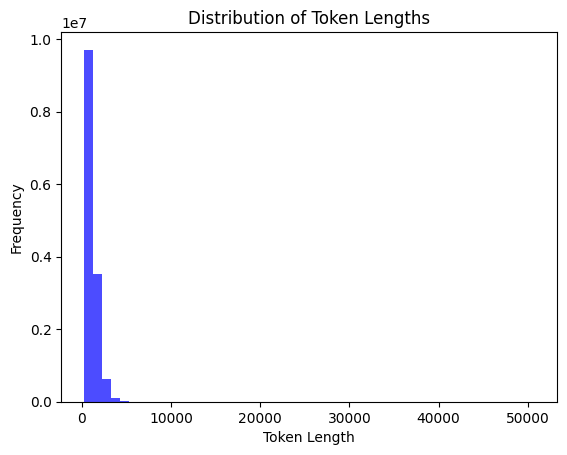

In [6]:
# token_lengths = [len(x) for x in tokenized_ds["length"]]

plt.hist(tokenized_ds["length"], bins=50, color='blue', alpha=0.7)
plt.xlabel("Token Length")
plt.ylabel("Frequency")
plt.title("Distribution of Token Lengths")
plt.show()

In [7]:
max_length = max(tokenized_ds["length"])
print(f"Max length: {max_length}")

Max length: 50781


In [8]:
# filter out examples with length > 2048
filtered_ds = tokenized_ds.filter(lambda x: x["length"] <= 2048)

Filter:   0%|          | 0/13972791 [00:00<?, ? examples/s]

In [9]:
filtered_ds

Dataset({
    features: ['problem', 'generated_solution', 'expected_answer', 'problem_source', 'length'],
    num_rows: 12935705
})